In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

diab = np.genfromtxt('diabetes.csv', delimiter=',', skip_header=1)

In [ ]:
# as colunas de 1 a 5 não podem ter zeros, então substituímos com a mediana.

for i in range(1,6):
    col = diab[:,i]
    mediana = np.median(col[col != 0])
    col[col == 0] = mediana

In [16]:
# agora vamos normalizar os dados, com z-escore

X_puro = diab[:,:-1]
y_puro = diab[:,-1]

media_x = np.mean(X_puro, axis=0)
desvio_x = np.std(X_puro, axis=0)
X_norm = (X_puro - media_x) / desvio_x

# obs: não se normaliza o y em classificação! afinal, é 0 ou 1.

In [ ]:
# vamos separar em treino e teste

N = len(X_norm)

indices = np.random.permutation(N)
X = X_norm[indices]
y = y_puro[indices]

tam_treino = int(0.8*N)
tam_teste = N - tam_treino

X_treino = X[:tam_treino]
y_treino = y[:tam_treino]

X_teste = X[tam_treino:]
y_teste = y[tam_treino:]

Acurácia no teste: 0.7662337662337663
Precisão: 0.8056
Recall: 0.5000
F1-Score: 0.6170


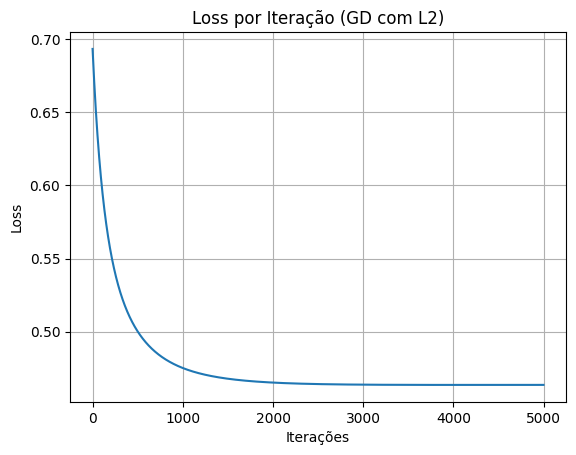

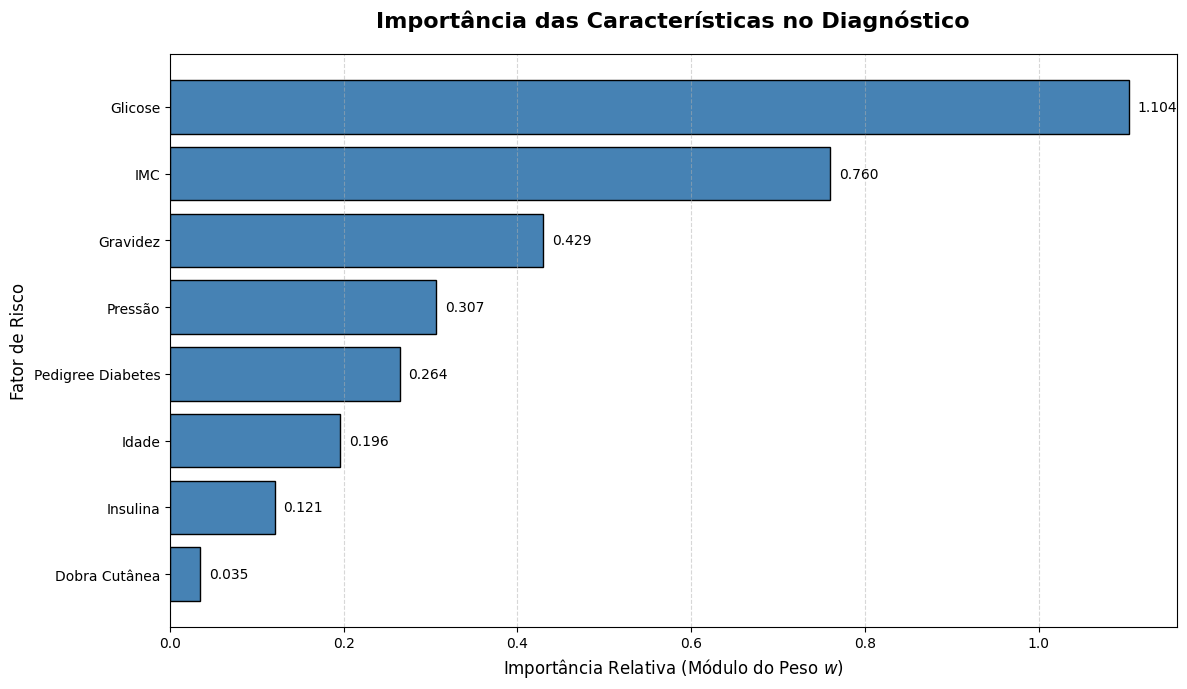

In [ ]:
# efetuando a regressão logistica

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w = np.zeros(X_treino.shape[1])
b = 0
alpha = 0.01
lambd = 1 # hiperparâmetro de regularização L2

loss_hist = []
for t in range(1, 5000):
    z = X_treino @ w + b
    y_pred = sigmoid(z)
    
    loss = -np.mean(y_treino * np.log(y_pred) + (1 - y_treino) * np.log(1 - y_pred)) + lambd * np.sum(w**2) / (2*tam_treino)
    loss_hist.append(loss)

    w = w - alpha *( X_treino.T @ (y_pred - y_treino) )/ tam_treino + alpha*lambd* w / tam_treino
    b = b - alpha * np.mean(y_pred - y_treino)
    # if t % 100 == 0:
    #     print(f'Iteração {t}, Loss: {loss:.4f}')

y_prob_teste = sigmoid(X_teste @ w + b)
y_pred_teste = (y_prob_teste >= 0.5).astype(int)

print("Acurácia no teste:", np.mean(y_pred_teste == y_teste))

plt.plot(range(len(loss_hist)), loss_hist)
plt.title("Loss por Iteração (GD com L2)")
plt.xlabel("Iterações")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# gráfico de importância das características

nomes= [
    'Gravidez', 'Glicose', 'Pressão', 'Dobra Cutânea', 
    'Insulina', 'IMC', 'Pedigree Diabetes', 'Idade'
]


importancia_map = {nome: abs(peso) for nome, peso in zip(nomes, w)}
importancia_ord = sorted(importancia_map.items(), key=lambda x: x[1], reverse=True)
nomes_ordenados, valores_ordenados = zip(*importancia_ord)


plt.figure(figsize=(12, 7))
plt.barh(nomes_ordenados, valores_ordenados, color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Importância das Características no Diagnóstico', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importância Relativa (Módulo do Peso $w$)', fontsize=12)
plt.ylabel('Fator de Risco', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(valores_ordenados):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()